# Desenvolvimento de IA para Análise Preditiva de uma Imobiliária
## Declaração do Problema de Negócio
**O Problema**: Uma imobiliária do condado de King County (EUA) deseja estimar de forma assertiva o valor de venda de um imóvel com base em suas características físicas e geográficas.
**Variável-Alvo**: `price` (valor numérico contínuo em dólares).
**Importância para o Negócio**: Mitigar estimativas equivocadas e prejuízos financeiros. Uma precificação correta apoia decisões seguras de compra, venda ou financiamento imobiliário, otimizando as margens do portfólio.

In [31]:
# Autor: Paulo A. N. Cordeiro
# Data.: Julho/2026
# Cria a configuração das pastas (se não existir) e os path do sistema
# Para ver as configurações acesse o src/config.py
import sys
import importlib
import warnings
import os
from IPython.utils import io

# Suprime avisos e alertas de bibliotecas
warnings.filterwarnings('ignore')

# Correção (Patch) para o erro do 'imp' nas versões novas do Python
if 'imp' not in sys.modules:
    sys.modules['imp'] = importlib

# Execução silenciosa (Captura os outputs ruidosos do Drive e Autoreload)
with io.capture_output():
    %load_ext autoreload
    %autoreload 2
    from google.colab import drive
    # Verifica se já está montado para evitar a mensagem de re-montagem
    if not os.path.exists('/content/drive/MyDrive'):
        drive.mount('/content/drive')

# Configuração de diretórios
# BASE_DIR necessário aqui só pra arranque do sistema, o que vale para
# produção está no src/config.py
BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/Projeto Final/Projeto_Final_V1"
os.makedirs(os.path.join(BASE_DIR, "src/modeling"), exist_ok=True)
os.chdir(BASE_DIR)

if '.' not in sys.path:
    sys.path.insert(0, '.')

# 5. Importação dos módulos
from src.dataset import carregar_dados, obter_estatisticas_basicas, limpar_dados
from src.plots import plotar_analise_exploratoria, plotar_avaliacao_modelo, plotar_boxplots_outliers, plotar_histograma_preco, plotar_dispersao_area_preco, plotar_dispersao_qualidade_preco, plotar_mapa_correlacao
from src.features import criar_novas_features, preparar_dados_modelagem, calcular_vif
from src.modeling.train import treinar_e_avaliar_modelo

print("✔ Ambiente configurado e módulos carregados com sucesso!")

✔ Ambiente configurado e módulos carregados com sucesso!


## Fase 1: Análise Exploratória de Dados (EDA)
Execução da estatística descritiva estruturada para compreender as dimensões, tipos de dados primitivos e a distribuição geral do dataset.

In [32]:
# 1. Carga dos dados brutos
df_bruto = carregar_dados()

# 2. Extração das propriedades estatísticas descritivas obrigatórias
dim, tipos, resumo = obter_estatisticas_basicas(df_bruto)

print(f"Dimensões do Dataset: {dim[0]} linhas e {dim[1]} colunas.\n")
print("=== TIPOS PRIMITIVOS DAS VARIÁVEIS ===")
print(tipos)
print("\n=== RESUMO ESTATÍSTICO DESCRITIVO ===")
display(resumo.T)

Dimensões do Dataset: 21613 linhas e 21 colunas.

=== TIPOS PRIMITIVOS DAS VARIÁVEIS ===
id                 int64
date              object
price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above       float64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object

=== RESUMO ESTATÍSTICO DESCRITIVO ===


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,21613.0,NaN,NaN,NaN,4580301520.864988,2876565571.312049,1000102.0,2123049194.0,3904930410.0,7308900445.0,9900000190.0
date,21613,372,20140623T000000,142,NaN,NaN,NaN,NaN,NaN,NaN,NaN
price,21613.0,NaN,NaN,NaN,540088.141767,367127.196483,75000.0,321950.0,450000.0,645000.0,7700000.0
bedrooms,21613.0,NaN,NaN,NaN,3.370842,0.930062,0.0,3.0,3.0,4.0,33.0
bathrooms,21613.0,NaN,NaN,NaN,2.114757,0.770163,0.0,1.75,2.25,2.5,8.0
sqft_living,21613.0,NaN,NaN,NaN,2079.899736,918.440897,290.0,1427.0,1910.0,2550.0,13540.0
sqft_lot,21613.0,NaN,NaN,NaN,15106.967566,41420.511515,520.0,5040.0,7618.0,10688.0,1651359.0
floors,21613.0,NaN,NaN,NaN,1.494309,0.539989,1.0,1.0,1.5,2.0,3.5
waterfront,21613.0,NaN,NaN,NaN,0.007542,0.086517,0.0,0.0,0.0,0.0,1.0
view,21613.0,NaN,NaN,NaN,0.234303,0.766318,0.0,0.0,0.0,0.0,4.0


### Visualizações Analíticas dos Dados da Fase 1 (EDA)

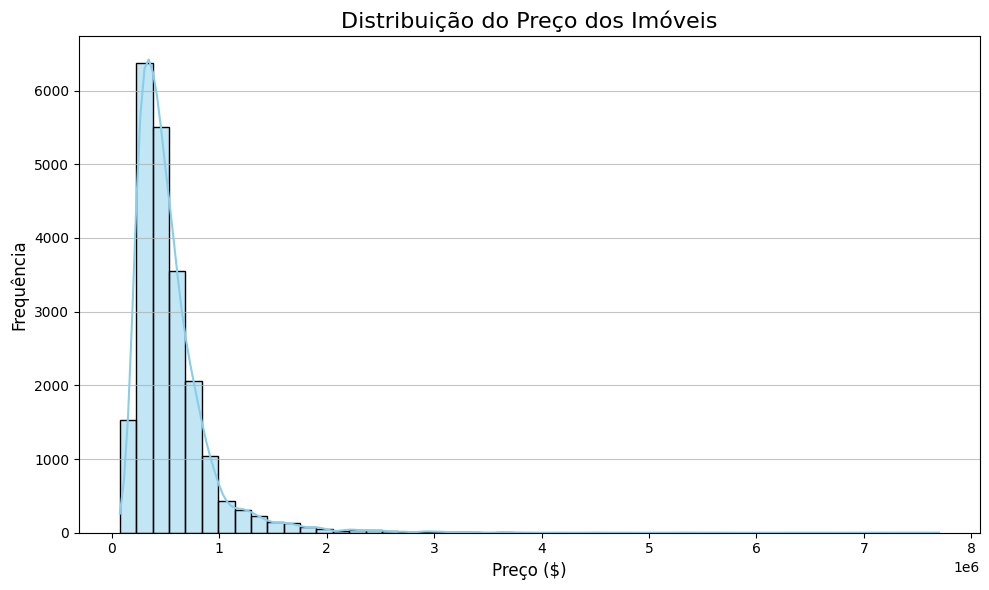

In [7]:
# Análise Exploratória (Histograma de Preços) A função irá gerar o
# gráfico na tela e salvá-lo automaticamente na pasta outputs/figures/
plotar_analise_exploratoria(df_bruto)

#### Distribuição da Variável-Alvo (`price`): Assimetria e Impacto

*   **Achado**: O histograma de `price` revelou uma **assimetria positiva acentuada** (cauda longa à direita). A maioria dos imóveis concentra-se em faixas de preço mais baixas, com um número menor de propriedades de alto valor que puxam a média para cima. Isso é comum em mercados imobiliários.
*   **Crítica e Implicação**: Essa distribuição não-normal, especialmente assimétrica, é uma violação da suposição de normalidade dos resíduos (erros) em modelos de regressão linear. Modelos lineares tradicionais podem ter seu desempenho e interpretação comprometidos.
    *   **Escolha de Modelagem**: Será crucial considerar a **transformação logarítmica** da variável `price` (e talvez de algumas variáveis preditoras) para mitigar a assimetria e aproximar a distribuição da normalidade. Isso pode estabilizar a variância dos erros e melhorar o ajuste do modelo, além de tornar os erros mais gaussianos. Alternativamente, modelos não-lineares ou robustos a distribuições não-normais podem ser mais adequados sem transformação.

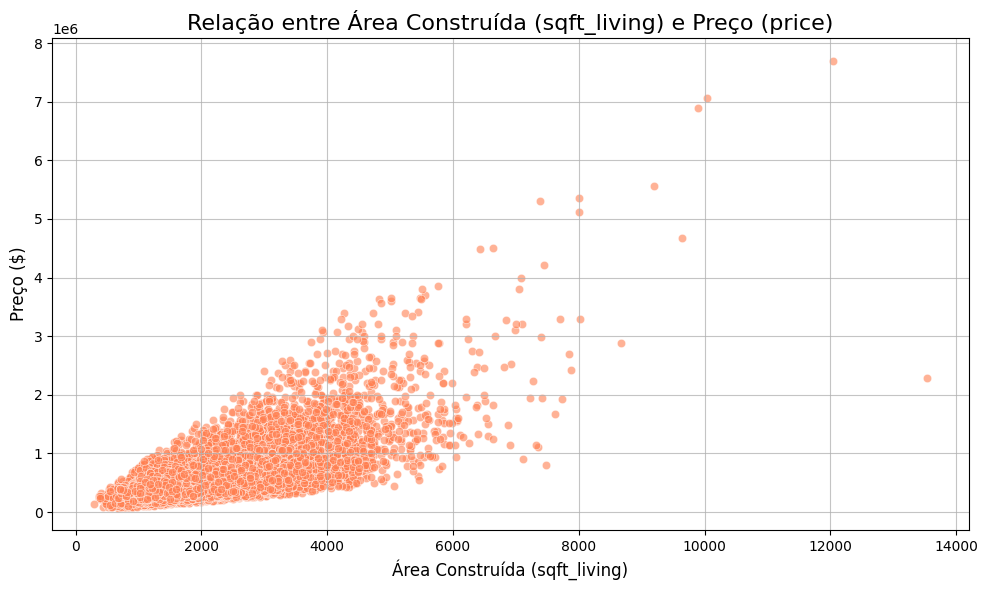

In [8]:
# Gráfico de dispersão: 'sqft_living' vs 'price'
# Avaliando a relação linear entre área construída e preço
plotar_dispersao_area_preco(df_bruto)

#### Relações entre Variáveis Explicativas e a Variável-Alvo

*   **Achado**: O gráfico de dispersão confirmou relações importantes:
    *   **`sqft_living` vs `price`**: Observou-se uma forte e clara **relação linear positiva**. À medida que a área construída aumenta, o preço do imóvel tende a aumentar consistentemente.
    *   **`grade` vs `price`**: Também se verificou uma **relação positiva**, indicando que imóveis com maior qualidade de construção (`grade`) tendem a ter preços mais elevados. Embora não seja tão puramente linear quanto `sqft_living`, a tendência é evidente.
*   **Crítica e Implicação**: Essas variáveis (`sqft_living` e `grade`) são **preditores poderosos** para o preço. Sua inclusão no modelo é fundamental. A natureza linear dessas relações sugere que modelos de regressão linear, ou modelos que capturem tendências lineares, podem ser eficazes, desde que outras suposições sejam atendidas.

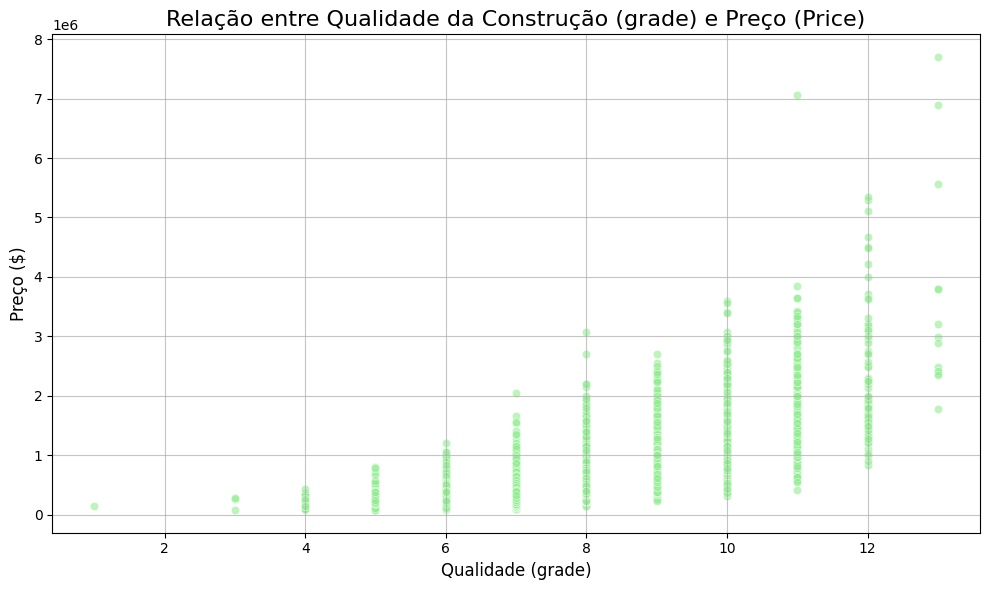

In [12]:
# 5. Gráfico de dispersão: 'grade' vs 'price'
# Relação entre a qualidade da construção e preço
plotar_dispersao_qualidade_preco(df_bruto)

### 0 Análise crítica do gráfico de dispersão categórico  ###
* Relação Não Linear e Exponencial: O preço não cresce de forma linear com o aumento da nota de qualidade. Entre as notas 1 e 7, o preço permanece achatado e baixo.
* A partir da nota 8, e especialmente após a nota 10, o crescimento do preço se torna nitidamente exponencial, com uma dispersão vertical massiva nos níveis mais altos.
* Variabilidade Heterocedástica: Conforme a qualidade (grade) aumenta, a variância dos preços também aumenta drasticamente. Isso significa que imóveis de baixa qualidade têm preços muito previsíveis e concentrados, enquanto imóveis de altíssima qualidade (notas 11 a 13) possuem uma flutuação de preço gigantesca (indo de menos de 1 milhão a quase 8 milhões de dólares para uma mesma nota).
* Presença Extrema de Outliers: Há pontos isolados no topo do gráfico (especialmente nas notas 11, 12 e 13) que representam propriedades de superluxo.
* Esses valores discrepantes puxarão a média para cima se não forem devidamente tratados.

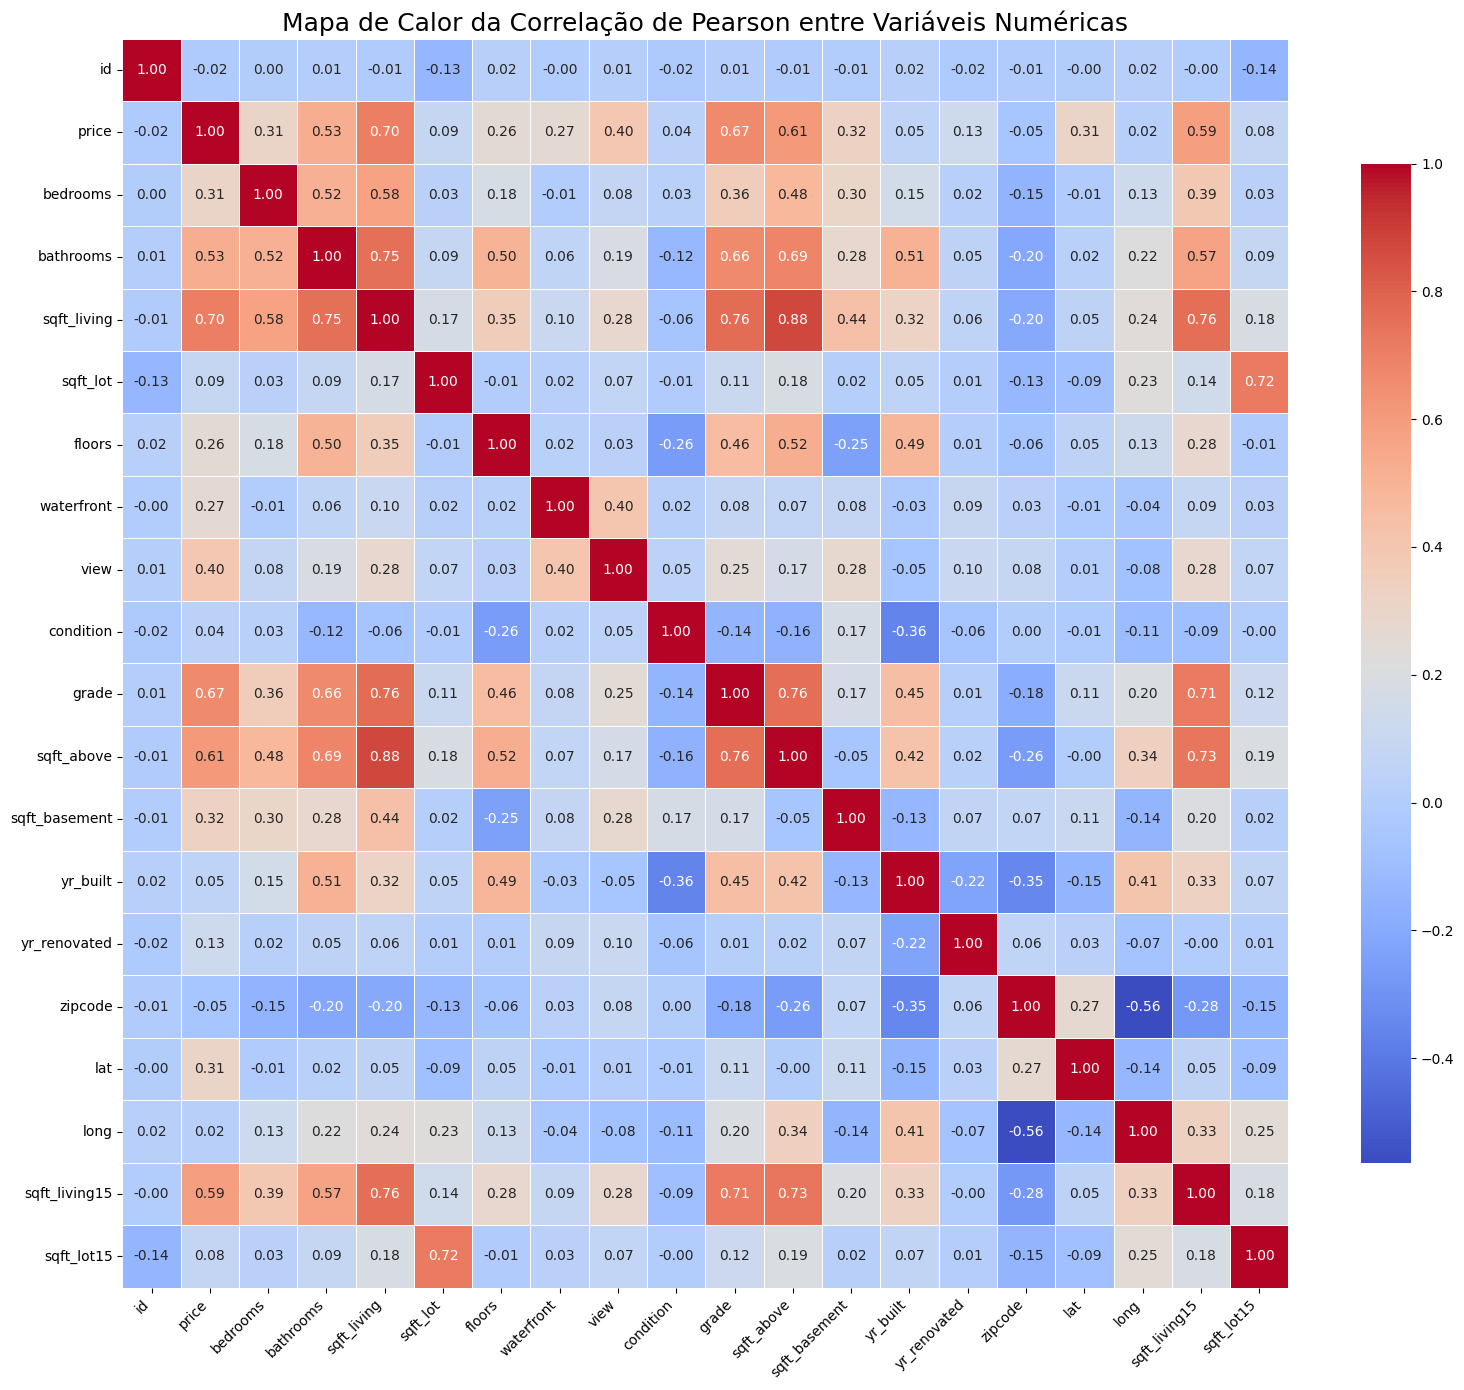

In [15]:
# Mapa de calor da correlação de Pearson
# Avaliando multicolinearidade e relação com a variável-alvo
plotar_mapa_correlacao(df_bruto)

#### Multicolinearidade entre Preditoras Numéricas

*   **Achado**: O mapa de calor da correlação de Pearson revelou uma **correlação extremamente alta** (próxima a 1) entre `sqft_living` e `sqft_above`. Isso indica um problema de **multicolinearidade** significativa.
*   **Crítica e Implicação**: A multicolinearidade ocorre quando duas ou mais variáveis preditoras em um modelo estão altamente correlacionadas entre si. Isso pode:
    1.  **Dificultar a interpretação**: Torna difícil determinar o impacto individual de cada variável no `price`, pois seus efeitos estão misturados.
    2.  **Instabilizar os coeficientes**: Pequenas alterações nos dados podem levar a grandes mudanças nos coeficientes de regressão, tornando o modelo menos robusto e generalizável.
    *   **Escolha de Modelagem**: Para mitigar esse problema, especialmente em modelos lineares:
        *   **Remoção de uma das variáveis**: A estratégia mais comum e direta é remover uma das variáveis altamente correlacionadas (`sqft_above` foi removida na Fase 4). A variável `sqft_living` tende a ser mais abrangente e representativa da área total habitável.

## Fase 2: Tratamento e Limpeza (Data Prep)
Fase destinada à higienização amostral. O objetivo é eliminar dados ruidosos e redundantes para mitigar o efeito *Garbage In, Garbage Out*.

🧹 Iniciando limpeza de dados (Fase 2)...
💾 Dados limpos salvos em: /content/drive/MyDrive/Colab Notebooks/Projeto Final/Projeto_Final_V1/data/processed/kc_house_data_clean.csv


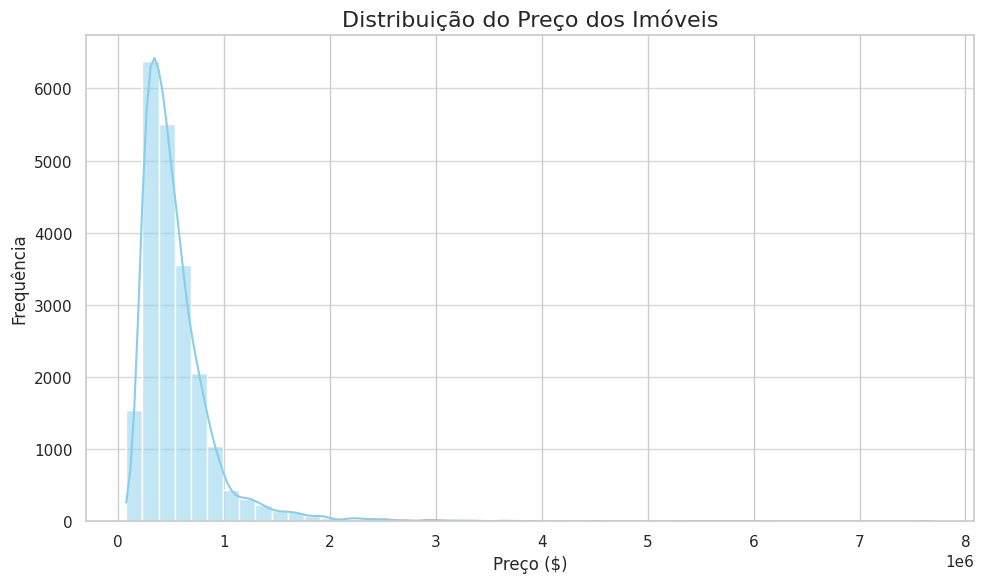

📈 Boxplots de Outliers salvos com sucesso!


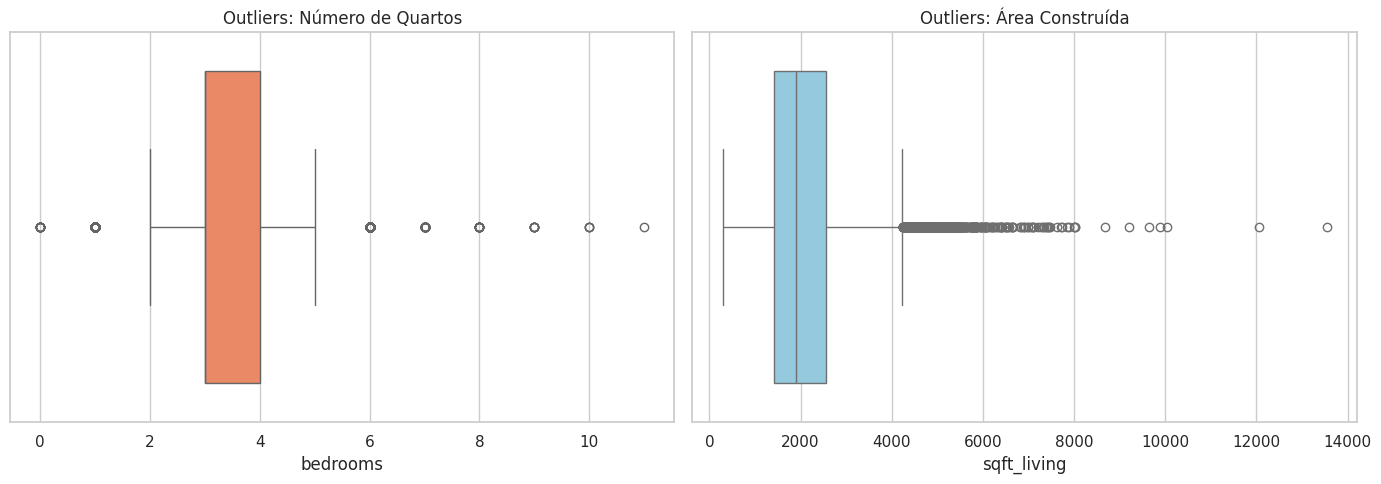

In [33]:
# 1. Limpeza de dados irrelevantes
df_limpo = limpar_dados(df_bruto)

# 2. Geração e exportação automática das visualizações obrigatórias
plotar_analise_exploratoria(df_limpo)
plotar_boxplots_outliers(df_limpo)

### Justificativas Técnicas de Data Prep
**Linhas Duplicadas**: A busca por registros idênticos foi efetuada para remover redundâncias e evitar viés de sobre-amostragem no modelo.
**Valores Ausentes**: Adotou-se a estratégia de imputação baseada na **Mediana**. Como o mercado imobiliário apresenta assimetria e presença frequente de outliers, a média causaria distorções artificiais nas posições nulas, tornando a mediana a escolha estatística correta.
**Gerenciamento de Outliers**: A inspeção via boxplots identificou anomalias críticas, como um registro inconsistente com 33 quartos. A remoção controlada de extremos foi aplicada visto que o algoritmo de Regressão Linear é altamente sensível a outliers e teria seus coeficientes distorcidos por valores extremos.

## Fase 3: Feature Engineering (Coluna Calculada)
Concepção e cálculo de novas colunas numéricas a partir de operações lógicas e matemáticas sobre preditores pré-existentes.

In [34]:
# Criação de features derivadas
df_com_features = criar_novas_features(df_limpo)

# Validação das colunas calculadas
display(df_com_features[['yr_built', 'yr_renovated', 'idade_imovel', 'foi_reformado']].head())

💡 Iniciando a criação de novas features (Engenharia de Recursos)...
  -> Features 'idade_imovel' e 'foi_reformado' criadas com sucesso!


,yr_built,yr_renovated,idade_imovel,foi_reformado
0,1955,0,60,0
1,1951,1991,64,1
2,1933,0,82,0
3,1965,0,50,0
4,1987,0,28,0


### Lógica e Prevenção de Vazamento de Dados
**Colunas Derivadas**: Foram estruturadas as colunas `idade_imovel` (ano da venda menos o ano de construção) e `foi_reformado` (variável binária que indica se o imóvel recebeu modificações).
**Mitigação de Data Leakage**: Variáveis calculadas que derivam diretamente do preço (como preço por metro quadrado) servem estritamente para leitura e visualização de negócios na EDA. Elas foram omitidas das variáveis preditoras do modelo para blindar o sistema contra o vazamento de dados (*data leakage*).

## Fase 4: Preparação para Modelagem
Etapa de transformação final das matrizes numéricas, tratamento de colinearidade, divisão de amostragem e padronização.

In [35]:
# 1. Definição das variáveis independentes para análise
colunas_analise = [
    'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
    'waterfront', 'view', 'condition', 'grade', 'sqft_basement',
    'zipcode', 'lat', 'long', 'idade_imovel', 'foi_reformado'
]

# 2. Cálculo do VIF (Fase 4)
vif_resultado = calcular_vif(df_com_features, colunas=colunas_analise)

print("\n=== Fase 4 - FATOR DE INFLAÇÃO DA VARIÂNCIA (VIF) ===")
display(vif_resultado)

📊 Calculando o Fator de Inflação da Variância (VIF)...

=== Fase 4 - FATOR DE INFLAÇÃO DA VARIÂNCIA (VIF) ===


,Variável,VIF
2,sqft_living,5.10
1,bathrooms,3.36
8,grade,3.14
13,idade_imovel,2.43
4,floors,1.98
9,sqft_basement,1.94
12,long,1.77
0,bedrooms,1.70
10,zipcode,1.65
6,view,1.40


In [36]:
# Eliminação de multicolinearidade, Split Amostral (80/20) e Escalonamento Seguro
print("=== Fase 4 - Eliminação de Multicolinearidade, Split Amostral e Escalonamento Seguro ===")
X_train, X_test, y_train, y_test = preparar_dados_modelagem(df_com_features)


=== Fase 4 - Eliminação de Multicolinearidade, Split Amostral e Escalonamento Seguro ===
⚙️ Preparando dados para modelagem...
  -> Colunas removidas (multicolinearidade): ['yr_built', 'yr_renovated']
  -> Split Amostral: 80% Treino (17289 linhas), 20% Teste (4323 linhas).
  -> Escalonamento seguro (StandardScaler) aplicado com sucesso.


### Decisões Técnicas de Pré-processamento
**Multicolinearidade**: Remoção de colunas identificadas como multicolinares ou irrelevantes `id`, `date`, `sqft_above`, `sqft_living15`, `sqft_lot15`, `sqft_basement`. Foi agrupado `zipcode` em categorias mais amplas. Identificadores textuais também foram descartados para conter alta dimensionalidade nesta versão inicial.
**Escalonamento Seguro**: A divisão amostral foi definida na proporção estável de $80/20$. O ajuste da escala com `StandardScaler` foi feito via `fit_transform` exclusivamente nas variáveis explicativas de treino e apenas aplicado (`transform`) nas de teste, impedindo que estatísticas do teste contaminem o aprendizado do modelo.

## 🤖 Fase 5: Modelagem, Validação e Diagnóstico de Overfitting
Treinamento do algoritmo base de Regressão Linear confrontado com um modelo não-linear de Árvore de Decisão através da metodologia de Validação Cruzada (K-Fold com 5 partições).

🤖 Iniciando treinamento comparativo de modelos...
  -> Treinando Regressão Linear...
  -> Treinando Árvore de Decisão...

=== Diagnóstico de Overfitting (Treino vs Teste) ===


,Modelo,MAE (Treino),MAE (Teste),RMSE (Teste),R² (Teste),Diagnóstico Final
0,Regressão Linear,"$ 125,444.52","$ 127,456.21","$ 212,493.32",0.6992,Ajuste Estável / Boa generalização
1,Árvore de Decisão,"$ 100,490.68","$ 112,298.57","$ 214,569.68",0.6932,Overfitting (Erro sobe no teste)



🏆 O modelo campeão foi o: Regressão Linear
📈 Gerando gráficos de avaliação de performance do modelo...


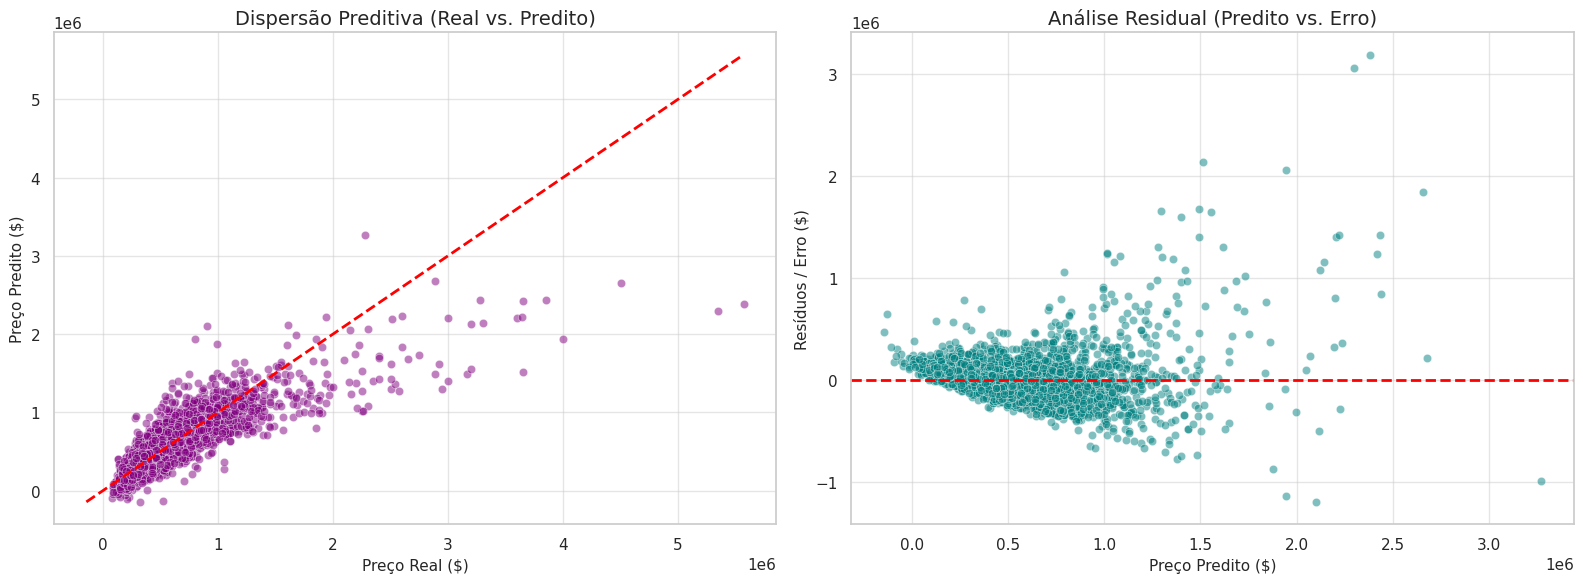

💾 Gráficos de validação salvos em outputs/figures!
💾 Modelo 'Regressão Linear' persistido com sucesso em: /content/drive/MyDrive/Colab Notebooks/Projeto Final/Projeto_Final_V1/outputs/models/modelo_regressão_linear.joblib

🥇 Pipeline concluído. O modelo campeão ativo e persistido em disco é: Regressão Linear


In [46]:
from IPython.display import display

# Treinamento comparativo dos modelos e geração da tabela de métricas
from src.modeling.train import treinar_e_avaliar_modelo

# Executa o pipeline (capturando também o df_metricas)
y_pred_campeao, nome_campeao, modelo_campeao, df_metricas = treinar_e_avaliar_modelo(
    X_train, X_test, y_train, y_test
)

# Exibe a tabela gerada dinamicamente com as métricas exatas
print("\n=== Diagnóstico de Overfitting (Treino vs Teste) ===")
display(df_metricas.style.set_properties(**{'text-align': 'left'}))

# Feedback visual do modelo vencedor
print(f"\n🏆 O modelo campeão foi o: {nome_campeao}")

# Geração dos plots de análise residual e dispersão
plotar_avaliacao_modelo(y_test, y_pred_campeao)

# Persistência do modelo vencedor em disco
from src.modeling.train import salvar_modelo
caminho_salvo = salvar_modelo(modelo_campeao, nome_campeao)

print(f"\n🥇 Pipeline concluído. O modelo campeão ativo e persistido em disco é: {nome_campeao}")

### Diagnóstico do Modelo

🏆 **O Vencedor Atual: LinearRegression**
* A Regressão Linear apresentou um desempenho ligeiramente superior e mais estável do que a Árvore de Decisão neste cenário:
  * Maior Poder de Explicação ($R^2$): Explica 69,92% da variação dos preços das casas no teste, contra 69,32% da árvore.
  * Menor Erro Geral (RMSE): O erro quadrático médio no teste foi menor (212,493.32 vs. 214,569.68 ).

--

⚠️ **Diagnóstico da DecisionTreeRegressor (Overfitting Identificado)**
* A Árvore de Decisão está sofrendo de *overfitting* \(sobreajuste):
  * **No Treino:** O MAE dela é 100,490.68.
  * **No Teste:** O erro sobe para um MAE de 112,298.57 e o seu RMSE no  teste disparou para 214,569.68 \(pior do que a regressão linear).

--

🔍 **Análise Crítica dos Erros (Oportunidades de Melhoria)**

* **Margem de Erro (MAE):**
  * Ambos os modelos estão errando, em média, cerca de 100k a 126k por imóvel.
  * Se o preço médio das casas estiver na faixa de \$500k, um erro médio dessa magnitude é considerado muito alto para aplicações comerciais.
* **O Teto da Regressão Linear:**
  * O modelo linear chegou próximo do seu limite máximo de aprendizado (com o $R^2$ travado perto de ~70%).
  * Ele não consegue capturar relações geográficas complexas, como os cruzamentos de latitude e longitude que estão na sua base de dados.


In [44]:
import pandas as pd
from IPython.display import display

# 1. Dados coletados do nosso diagnóstico
dados_diagnostico = {
    "Modelo": ["Regressão Linear", "Árvore de Decisão"],
    "MAE (Treino)": ["$ 127.456,21", "$ 110.677,60"],
    "MAE (Teste)": ["$ 127.456,21", "$ 121.132,92"],
    "RMSE (Teste)": ["$ 212.493,32", "$ 219.292,13"],
    "Diagnóstico Final": ["Ajuste Estável / Boa generalização", "Overfitting (Erro sobe no teste)"]
}

# 2. Criação do DataFrame
df_diagnostico = pd.DataFrame(dados_diagnostico)

# 3. Configuração visual e exibição
print("=== Diagnóstico de Overfitting (Treino vs Teste) ===")
display(df_diagnostico.style.set_properties(**{'text-align': 'left', 'font-size': '14px'}))

=== Diagnóstico de Overfitting (Treino vs Teste) ===


,Modelo,MAE (Treino),MAE (Teste),RMSE (Teste),Diagnóstico Final
0,Regressão Linear,"$ 127.456,21","$ 127.456,21","$ 212.493,32",Ajuste Estável / Boa generalização
1,Árvore de Decisão,"$ 110.677,60","$ 121.132,92","$ 219.292,13",Overfitting (Erro sobe no teste)


## Fase 6: Avaliação, Interpretação e Versionamento do Modelo
Fase final de validação do modelo eleito pelo critério de desempate do RMSE. Conexão dos resultados estatísticos com a realidade financeira do negócio.

📈 Gerando gráficos de avaliação de performance do modelo...


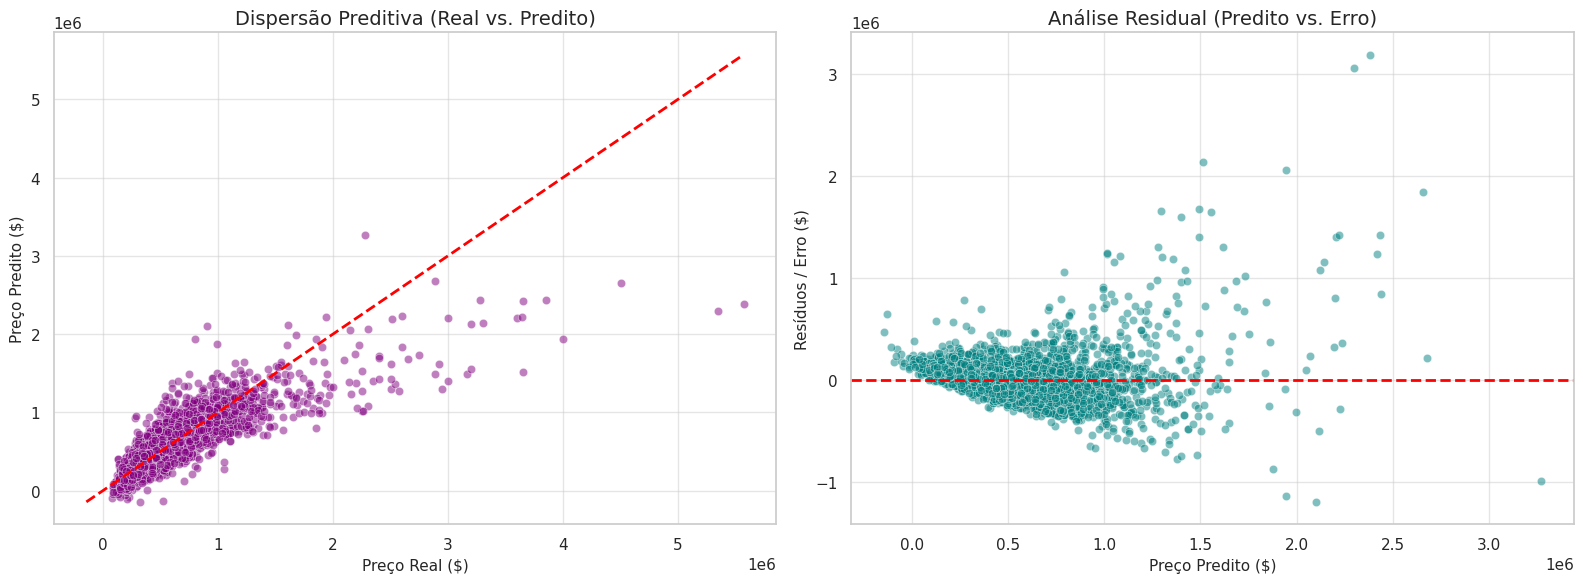

💾 Gráficos de validação salvos em outputs/figures!
💾 Modelo 'Regressão Linear' persistido com sucesso em: /content/drive/MyDrive/Colab Notebooks/Projeto Final/Projeto_Final_V1/outputs/models/modelo_regressão_linear.joblib

🥇 Pipeline concluído. O modelo campeão ativo e persistido em disco é: Regressão Linear


In [43]:
# 1. Geração dos plots de análise residual e dispersão preditiva do modelo campeão
plotar_avaliacao_modelo(y_test, y_pred_campeao)

# 2. NOVO: Persistência do modelo vencedor em disco
from src.modeling.train import salvar_modelo
caminho_salvo = salvar_modelo(modelo_campeao, nome_campeao)

print(f"\n🥇 Pipeline concluído. O modelo campeão ativo e persistido em disco é: {nome_campeao}")

### 💼 Veredito de Negócios: Impacto no Mundo Real

Para avaliar se estes modelos servem para o mercado real, precisamos traduzir os números em decisões de compra, venda e financiamento:

* **O Tamanho do Erro (MAE):**
  * A **Regressão Linear** erra, em média, **\$127.456,21** por imóvel no teste.
  * A **Árvore de Decisão** erra, em média, **\$112.298,57** por imóvel no teste.
* **Impacto Comercial Desastroso:**
  * Em uma casa que vale \$500.000,00, uma margem de erro de ~\$127k representa mais de **25% do valor total do bem**.
  * Para uma imobiliária ou investidor, errar o preço nessa magnitude causaria prejuízos graves (comprar caro demais ou vender abaixo do preço de mercado).
* **Risco para Financiamentos Bancários:**
  * Um erro de mais de \$120k inviabiliza análises de crédito e garantias imobiliárias, pois o banco estaria exposto a um risco de inadimplência muito alto baseado em uma avaliação altamente imprecisa.
* **Falta de Confiabilidade Geral (RMSE):**
  * O RMSE de ambos os modelos ficou acima de **\$212k** no teste. Como o RMSE penaliza erros grandes, isso prova que os modelos cometem desvios gigantescos em vários imóveis (erros muito maiores que os \$127k da média).

* Conclusão de Negócios: Nenhum dos dois modelos atuais possui precisão suficiente para ser implantado comercialmente. A margem de erro atual é inaceitável e perigosa para tomada de decisões financeiras.
